[*********************100%***********************]  1 of 1 completed


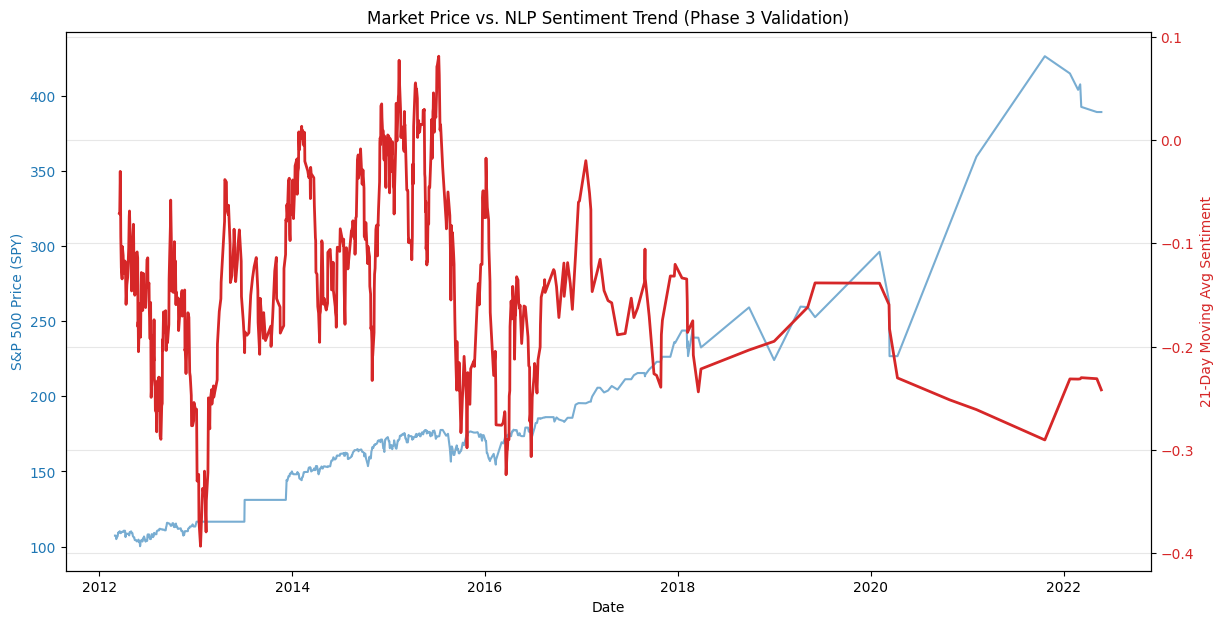

Correlation between Sentiment and Daily Returns: -0.0026


In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your sentiment features
sentiment_df = pd.read_parquet('../data/interim/sentiment_daily.parquet')

# 2. Fetch S&P 500 (SPY) prices
start_date = sentiment_df.index.min()
end_date = sentiment_df.index.max()
spy = yf.download('SPY', start=start_date, end=end_date)

# 3. Align and Merge
# We use a left join to keep all sentiment dates and forward-fill the stock prices
analysis_df = sentiment_df.copy()
analysis_df['SPY_Close'] = spy['Close'].reindex(analysis_df.index).ffill()
analysis_df['SPY_Returns'] = analysis_df['SPY_Close'].pct_change()

# 4. Visualization: Price vs. Weighted Sentiment
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotting SPY Price
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('S&P 500 Price (SPY)', color=color)
ax1.plot(analysis_df.index, analysis_df['SPY_Close'], color=color, alpha=0.6, label='SPY Price')
ax1.tick_params(axis='y', labelcolor=color) # <--- Fixed 'y' with quotes

# Create a second y-axis for sentiment
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('21-Day Moving Avg Sentiment', color=color)

# Using a 21-day rolling mean to see the 'trend' more clearly [cite: 86]
sentiment_trend = analysis_df['sent_weighted'].rolling(window=21).mean()
ax2.plot(analysis_df.index, sentiment_trend, color=color, linewidth=2, label='Sentiment Trend')
ax2.tick_params(axis='y', labelcolor=color) # <--- Fixed 'y' with quotes

plt.title('Market Price vs. NLP Sentiment Trend (Phase 3 Validation)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Lead Analysis: Correlation
correlation = analysis_df[['sent_weighted', 'SPY_Returns']].corr().iloc[0, 1]
print(f"Correlation between Sentiment and Daily Returns: {correlation:.4f}")

In [3]:
# Check if today's sentiment predicts tomorrow's returns (Lag 1)
analysis_df['SPY_Returns_Next_Day'] = analysis_df['SPY_Returns'].shift(-1)
lag_corr = analysis_df[['sent_weighted', 'SPY_Returns_Next_Day']].corr().iloc[0, 1]
print(f"Lagged Correlation (Sentiment -> Tomorrow's Return): {lag_corr:.4f}")

Lagged Correlation (Sentiment -> Tomorrow's Return): -0.0276
